In [4]:
import pandas as pd
import numpy as np

# --- 1. Load the Data ---
# Replace 'your_file_path.csv' with the actual path to your downloaded CSV file.
try:
    df = pd.read_csv('../../datasets/AmazonIndia2023/amz_in_total_products_data_processed.csv')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: Make sure the CSV file is in the correct directory.")
    # As a fallback, create a dummy dataframe to allow the rest of the script to run for demonstration
    df = pd.DataFrame({
        'asin': ['B000000000'],
        'title': ['Sample Product'],
        'imgUrl': ['url'],
        'productURL': ['url'],
        'stars': [4.5],
        'reviews': [150],
        'price': [999.0],
        'listPrice': [1999.0],
        'categoryName': ['Electronics'],
        'isBestSeller': [False]
    })


# --- 2. Inspect the Head ---
# Display the first 5 rows to get a feel for the data
print("\n--- First 5 Rows of the Dataset ---")
display(df.head())


# --- 3. Check Data Types and Nulls ---
# Get a concise summary of the DataFrame, including data types and non-null counts
print("\n--- Dataset Info ---")
df.info()


# --- 4. Get Summary Statistics ---
# Generate descriptive statistics for the numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

✅ Dataset loaded successfully!

--- First 5 Rows of the Dataset ---


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,categoryName,isBestSeller,boughtInLastMonth
0,B08VJFZQ9S,प्लेन कैज़ुअल वियर बेसबॉल कैप पुरुषों और महिला...,https://m.media-amazon.com/images/I/61DK1GchGF...,https://www.amazon.in/dp/B08VJFZQ9S,0.0,0,299.0,499.0,पुरुषों के हैट्स और कैप्स,False,0
1,B08VJFYW5Q,"यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (काला, फ़्...",https://m.media-amazon.com/images/I/61+nwjWLUg...,https://www.amazon.in/dp/B08VJFYW5Q,0.0,0,299.0,499.0,पुरुषों के हैट्स और कैप्स,False,0
2,B08VJFYVX9,प्लेन कैज़ुअल वियर बेसबॉल कैप पुरुषों और महिला...,https://m.media-amazon.com/images/I/61DK1GchGF...,https://www.amazon.in/dp/B08VJFYVX9,0.0,0,275.0,300.0,पुरुषों के हैट्स और कैप्स,False,0
3,B08VJFXM7F,"यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (सफ़ेद, फ़...",https://m.media-amazon.com/images/I/516jdJhgbX...,https://www.amazon.in/dp/B08VJFXM7F,0.0,0,275.0,300.0,पुरुषों के हैट्स और कैप्स,False,0
4,B08VJFXFTJ,यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (लाल और का...,https://m.media-amazon.com/images/I/614bZrSzDT...,https://www.amazon.in/dp/B08VJFXFTJ,0.0,0,275.0,300.0,पुरुषों के हैट्स और कैप्स,False,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589160 entries, 0 to 1589159
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1589160 non-null  object 
 1   title              1589160 non-null  object 
 2   imgUrl             1589160 non-null  object 
 3   productURL         1589160 non-null  object 
 4   stars              1589160 non-null  float64
 5   reviews            1589160 non-null  int64  
 6   price              1589160 non-null  float64
 7   listPrice          1589160 non-null  float64
 8   categoryName       1589160 non-null  object 
 9   isBestSeller       1589160 non-null  bool   
 10  boughtInLastMonth  1589160 non-null  int64  
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 122.8+ MB

--- Descriptive Statistics ---


,stars,reviews,price,listPrice,boughtInLastMonth
count,1.589160e+06,1.589160e+06,1.589160e+06,1.589160e+06,1.589160e+06
mean,1.983742e+00,2.413798e+02,2.595396e+03,2.306358e+02,1.930979e+01
std,2.033305e+00,3.258698e+03,1.082319e+04,3.589431e+02,3.137722e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,3.190000e+02,0.000000e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,6.190000e+02,0.000000e+00,0.000000e+00
75%,4.000000e+00,1.400000e+01,1.499000e+03,4.990000e+02,0.000000e+00
max,5.000000e+00,6.349880e+05,1.042109e+06,9.999900e+02,6.000000e+04


In [5]:
# --- 1. Investigate Zero Values ---
# Count the number of products with 0 in key numerical columns
zero_price_count = (df['price'] == 0).sum()
zero_listprice_count = (df['listPrice'] == 0).sum()
zero_stars_count = (df['stars'] == 0).sum()

print(f"Products with price = 0: {zero_price_count}")
print(f"Products with listPrice = 0: {zero_listprice_count}")
print(f"Products with stars = 0 (unrated): {zero_stars_count}")


# --- 2. Create a Cleaned DataFrame ---
# For price analysis, products without a price are not useful.
# We will create a new DataFrame that filters these out.
df_cleaned = df[df['price'] > 0].copy()
print(f"\nOriginal number of products: {len(df)}")
print(f"Number of products after removing items with no price: {len(df_cleaned)}")


# --- 3. Engineer the 'discount_percentage' Feature ---
# We calculate discount only where listPrice is greater than 0 to avoid division by zero.
# Where listPrice is 0, we assume there is no discount.
def calculate_discount(row):
    if row['listPrice'] > 0 and row['listPrice'] > row['price']:
        return ((row['listPrice'] - row['price']) / row['listPrice']) * 100
    return 0

df_cleaned['discount_percentage'] = df_cleaned.apply(calculate_discount, axis=1)


# --- 4. Verify the New Feature ---
# Display the first few rows with the new column to check our work.
# We select columns that show the result clearly.
print("\n--- DataFrame Head with New 'discount_percentage' Column ---")
display(df_cleaned[['title', 'price', 'listPrice', 'discount_percentage']].head())

# Also, let's look at the summary statistics for the new column
print("\n--- Statistics for 'discount_percentage' ---")
display(df_cleaned['discount_percentage'].describe())

Products with price = 0: 92015
Products with listPrice = 0: 1057517
Products with stars = 0 (unrated): 779603

Original number of products: 1589160
Number of products after removing items with no price: 1497145

--- DataFrame Head with New 'discount_percentage' Column ---


,title,price,listPrice,discount_percentage
0,प्लेन कैज़ुअल वियर बेसबॉल कैप पुरुषों और महिला...,299.0,499.0,40.080160
1,"यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (काला, फ़्...",299.0,499.0,40.080160
2,प्लेन कैज़ुअल वियर बेसबॉल कैप पुरुषों और महिला...,275.0,300.0,8.333333
3,"यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (सफ़ेद, फ़...",275.0,300.0,8.333333
4,यूनीसेक्स कॉटन एडजस्टेबल बेसबॉल कैप (लाल और का...,275.0,300.0,8.333333



--- Statistics for 'discount_percentage' ---


count    1.497145e+06
mean     1.588646e+01
std      2.479813e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.338898e+01
max      9.728183e+01
Name: discount_percentage, dtype: float64

--- Summary Statistics for Price ---


count    1.497145e+06
mean     2.754910e+03
std      1.113110e+04
min      1.000000e+00
25%      3.550000e+02
50%      6.960000e+02
75%      1.599000e+03
max      1.042109e+06
Name: price, dtype: float64

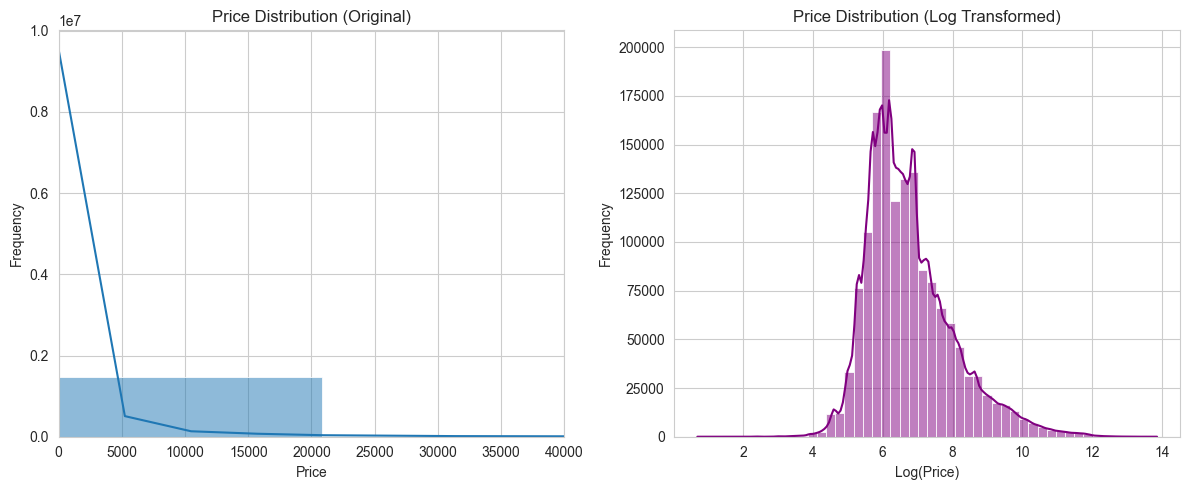


--- Product Count by Star Rating ---


stars
5.0    102302
4.9      1532
4.8      6801
4.7     15311
4.6     23126
4.5     31721
4.4     32008
4.3     37774
4.2     44253
4.1     47975
4.0     79001
3.9     48336
3.8     43907
3.7     39752
3.6     34468
3.5     32643
3.4     24176
3.3     20607
3.2     15688
3.1     12334
3.0     27987
2.9      8260
2.8      5842
2.7      5156
2.6      4033
2.5      5123
2.4      2706
2.3      1880
2.2      1516
2.1      1417
2.0      8454
1.9       714
1.8       586
1.7       511
1.6       433
1.5      1029
1.4       382
1.3       164
1.2        42
1.1         4
1.0     21110
Name: count, dtype: int64

C:\Users\sahar\AppData\Local\Temp\ipykernel_2516\578544168.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rated_products, x='stars', palette='viridis')


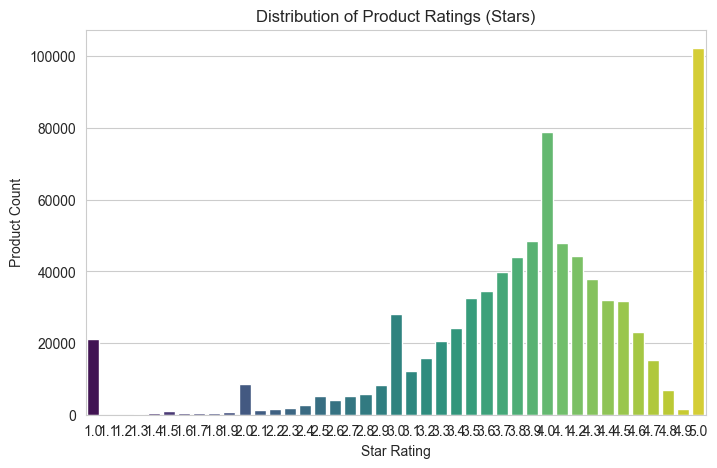


--- Product Count by Bestseller Status ---


isBestSeller
False    1494621
True        2524
Name: count, dtype: int64

C:\Users\sahar\AppData\Local\Temp\ipykernel_2516\578544168.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='isBestSeller', palette='pastel')


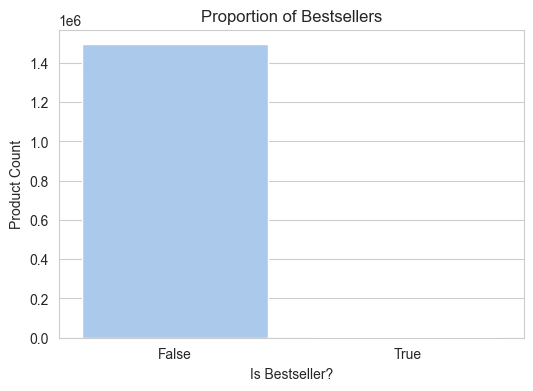


--- Top 10 Product Categories by Count ---


categoryName
खेल, फिटनेस और आउटडोर         35357
होम और किचन                   31358
पुरुषों के सनग्लासेस          26812
पुरुषों के शूज़                26679
Fashion Jewellery             24353
महिलाओं के जूते               23296
सूटकेस, चेक इन और स्ट्रॉली    23194
हैंडबैग और पर्स               20323
Amazon फैशन                   20111
मेकअप                         19748
Name: count, dtype: int64

C:\Users\sahar\AppData\Local\Temp\ipykernel_2516\578544168.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_categories.index, x=top_10_categories.values, orient='h', palette='rocket')
C:\Users\sahar\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sahar\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sahar\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\s

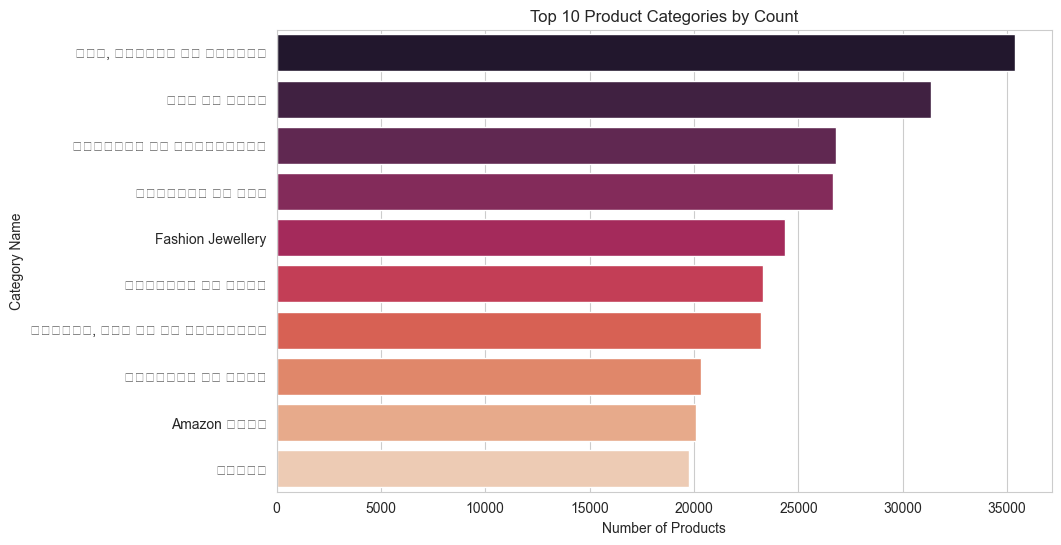

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for the plots
sns.set_style("whitegrid")

# --- Analyzing Numerical Variables ---

# 1. Price Distribution
# The best table for a skewed distribution like price is the .describe() output,
# which we already saw in Step 1. It gives us the mean, std, min, max, and quartiles.
print("--- Summary Statistics for Price ---")
display(df_cleaned['price'].describe())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['price'], bins=50, kde=True)
plt.xlim(0, 40000)
plt.title('Price Distribution (Original)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_cleaned['price']), bins=50, kde=True, color='purple')
plt.title('Price Distribution (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Stars Distribution
# We'll filter out 0-star (unrated) products for a clearer view.
rated_products = df_cleaned[df_cleaned['stars'] > 0]
print("\n--- Product Count by Star Rating ---")
stars_counts = rated_products['stars'].value_counts().sort_index(ascending=False)
display(stars_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=rated_products, x='stars', palette='viridis')
plt.title('Distribution of Product Ratings (Stars)')
plt.xlabel('Star Rating')
plt.ylabel('Product Count')
plt.show()

# --- Analyzing Categorical Variables ---

# 3. isBestSeller Proportion
print("\n--- Product Count by Bestseller Status ---")
bestseller_counts = df_cleaned['isBestSeller'].value_counts()
display(bestseller_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='isBestSeller', palette='pastel')
plt.title('Proportion of Bestsellers')
plt.xlabel('Is Bestseller?')
plt.ylabel('Product Count')
plt.show()


# 4. Top 10 Product Categories
print("\n--- Top 10 Product Categories by Count ---")
top_10_categories = df_cleaned['categoryName'].value_counts().nlargest(10)
display(top_10_categories)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_10_categories.index, x=top_10_categories.values, orient='h', palette='rocket')
plt.title('Top 10 Product Categories by Count')
plt.xlabel('Number of Products')
plt.ylabel('Category Name')
plt.show()